# Test Results and Visualizations

### Overview
This notebook is dedicated to the visual and statistical evaluation of the Machine Learning models trained in the previous step. The goal is to present clear, interpretable graphics that validate the model's performance and provide clinical insights into the EEG features.

### To-Do List:
1. **Load Models and Test Data:**
   * Load the test set (using the Subject-Wise split to maintain integrity).
   * Import the saved trained models (e.g., `.pkl` or `.joblib` files) from Notebook 02.

2. **Quantitative Performance Metrics:**
   * Generate a comprehensive classification report (Accuracy, Precision, Recall, F1-Score) for all three classes (AD, FTD, CN).
   * Create a comparative summary table to evaluate which algorithm performed best overall.

3. **Graphical Presentation of Results (Core Focus):**
   * **Confusion Matrix Heatmaps:** Plot highly visual, annotated matrices to identify specific misclassification trends (e.g., checking if the model struggles to differentiate FTD from AD).
   * **ROC-AUC Curves:** Plot Receiver Operating Characteristic curves for the multi-class problem to visualize the model's diagnostic capability across different thresholds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import os

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle

PROCESSED_DIR = '../data/processed/'
MODELS_DIR    = '../data/processed/models/'

sns.set_theme(style='whitegrid', palette='muted')
print('All imports successful.')

All imports successful.


In [2]:
# Load feature matrix
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'eeg_rbp_features.csv'))

# Load metadata saved by Notebook 02
le           = joblib.load(os.path.join(MODELS_DIR, 'label_encoder.joblib'))
FEATURE_COLS = joblib.load(os.path.join(MODELS_DIR, 'feature_cols.joblib'))

METADATA_COLS = ['subject_id', 'epoch_id', 'label']
X      = df[FEATURE_COLS].values
groups = df['subject_id'].values
y      = le.transform(df['label'].values)

CLASS_NAMES = list(le.classes_)   # e.g. ['AD', 'CN', 'FTD']
N_CLASSES   = len(CLASS_NAMES)

print(f'Dataset shape : {X.shape}')
print(f'Classes       : {CLASS_NAMES}')
print(f'Unique subjects: {len(np.unique(groups))}')

Dataset shape : (34788, 95)
Classes       : ['AD', 'CN', 'FTD']
Unique subjects: 88


In [3]:
# Load all trained models from Notebook 02
MODEL_FILES = {
    'KNN':                 'knn.joblib',
    'Decision Tree':       'decision_tree.joblib',
    'SVM':                 'svm.joblib',
    'Logistic Regression': 'logistic_regression.joblib',
    'LDA':                 'lda.joblib',
}

MODELS = {}
for name, fname in MODEL_FILES.items():
    path = os.path.join(MODELS_DIR, fname)
    MODELS[name] = joblib.load(path)
    print(f'  Loaded: {name}')

print(f'\n✓ {len(MODELS)} models loaded.')

  Loaded: KNN
  Loaded: Decision Tree
  Loaded: SVM
  Loaded: Logistic Regression
  Loaded: LDA

✓ 5 models loaded.


In [4]:
# Generate subject-wise test predictions using GroupKFold
# This mirrors the exact split used in Notebook 02 to maintain integrity
gkf = GroupKFold(n_splits=5)

# Collect out-of-fold predictions for each model
oof_preds  = {name: np.zeros(len(y), dtype=int)         for name in MODELS}
oof_probas = {name: np.zeros((len(y), N_CLASSES))       for name in MODELS}

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train         = y[train_idx]

    for name, pipeline in MODELS.items():
        pipeline.fit(X_train, y_train)
        oof_preds[name][test_idx]  = pipeline.predict(X_test)
        oof_probas[name][test_idx] = pipeline.predict_proba(X_test)

    print(f'  Fold {fold+1}/5 complete')

print('\n✓ Out-of-fold predictions generated for all models.')

  Fold 1/5 complete
  Fold 2/5 complete
  Fold 3/5 complete
  Fold 4/5 complete
  Fold 5/5 complete

✓ Out-of-fold predictions generated for all models.


In [5]:
# Comprehensive classification report for each model
for name in MODELS:
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(classification_report(y, oof_preds[name], target_names=CLASS_NAMES))


  KNN
              precision    recall  f1-score   support

          AD       0.46      0.49      0.47     14514
          CN       0.52      0.57      0.54     12012
         FTD       0.23      0.17      0.19      8262

    accuracy                           0.44     34788
   macro avg       0.40      0.41      0.40     34788
weighted avg       0.42      0.44      0.43     34788


  Decision Tree
              precision    recall  f1-score   support

          AD       0.48      0.48      0.48     14514
          CN       0.49      0.54      0.51     12012
         FTD       0.25      0.21      0.23      8262

    accuracy                           0.44     34788
   macro avg       0.41      0.41      0.41     34788
weighted avg       0.43      0.44      0.43     34788


  SVM
              precision    recall  f1-score   support

          AD       0.51      0.64      0.56     14514
          CN       0.57      0.61      0.59     12012
         FTD       0.21      0.09      0.13 

In [6]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Comparative summary table
rows = []
for name in MODELS:
    rows.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y, oof_preds[name]),
        'Precision': precision_score(y, oof_preds[name], average='macro', zero_division=0),
        'Recall'   : recall_score(y, oof_preds[name], average='macro', zero_division=0),
        'F1 Macro' : f1_score(y, oof_preds[name], average='macro', zero_division=0),
    })

summary_df = pd.DataFrame(rows).set_index('Model').sort_values('F1 Macro', ascending=False)

print('=== Comparative Summary Table ===')
display(summary_df.round(4))

best = summary_df['F1 Macro'].idxmax()
print(f'\n🏆 Best model by F1-Macro: {best} ({summary_df.loc[best, "F1 Macro"]:.4f})')

=== Comparative Summary Table ===


,Accuracy,Precision,Recall,F1 Macro
Model,,,,
LDA,0.5219,0.4712,0.4641,0.4487
Logistic Regression,0.5023,0.4421,0.4544,0.4427
SVM,0.4973,0.4271,0.4455,0.4261
Decision Tree,0.4368,0.4057,0.4100,0.4069
KNN,0.4401,0.4002,0.4082,0.4020



🏆 Best model by F1-Macro: LDA (0.4487)


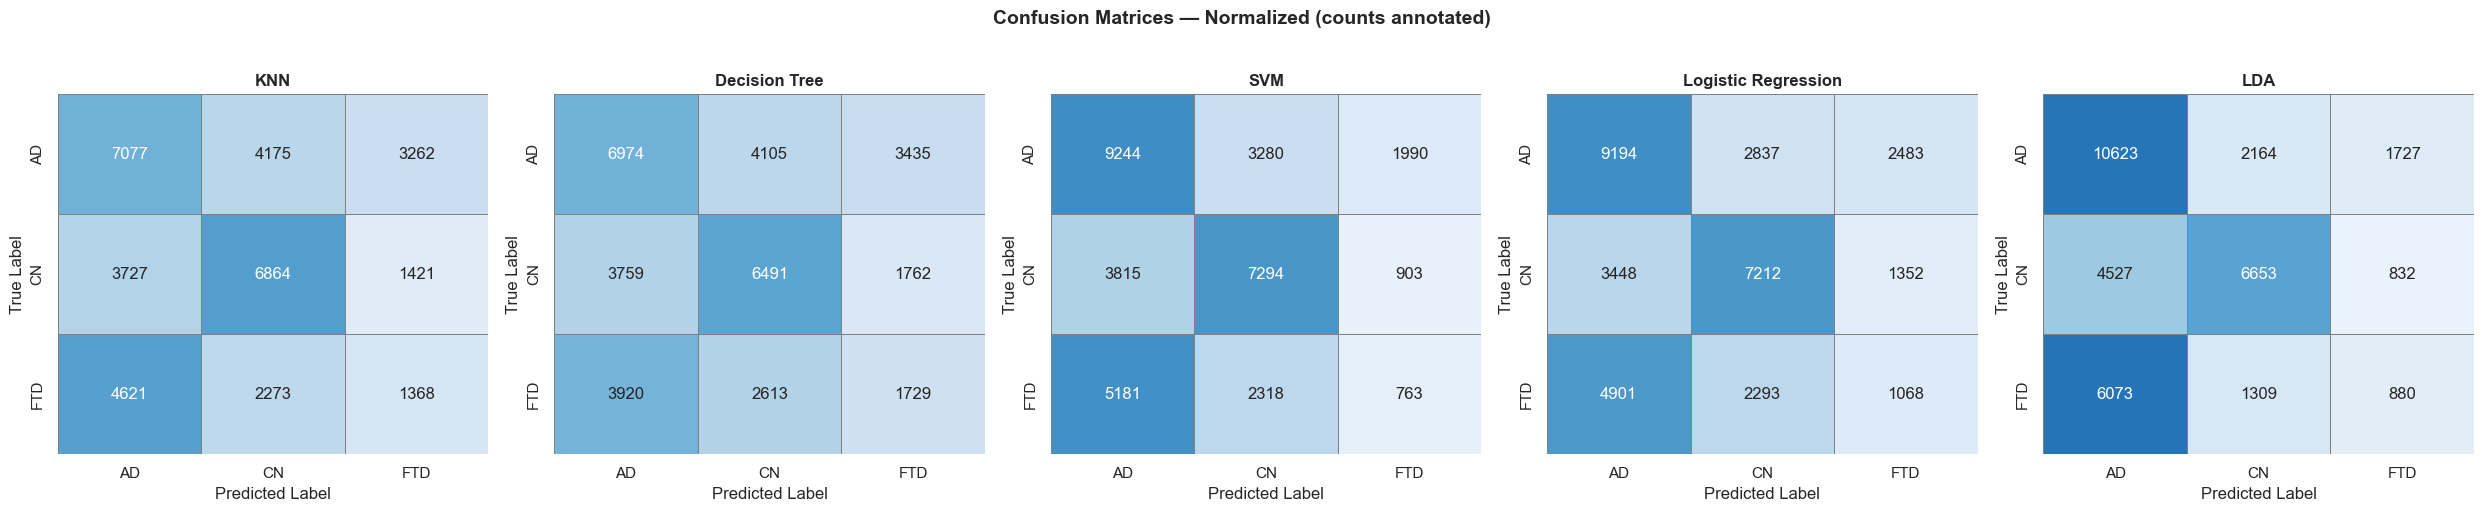

Saved: confusion_matrices.png


In [7]:
n_models = len(MODELS)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))

for ax, name in zip(axes, MODELS):
    cm = confusion_matrix(y, oof_preds[name])
    
    # Normalize per true class (row) for easier reading
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(
        cm_norm, annot=cm, fmt='d',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        cmap='Blues', vmin=0, vmax=1,
        linewidths=0.5, linecolor='gray',
        ax=ax, cbar=False
    )
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

fig.suptitle('Confusion Matrices — Normalized (counts annotated)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

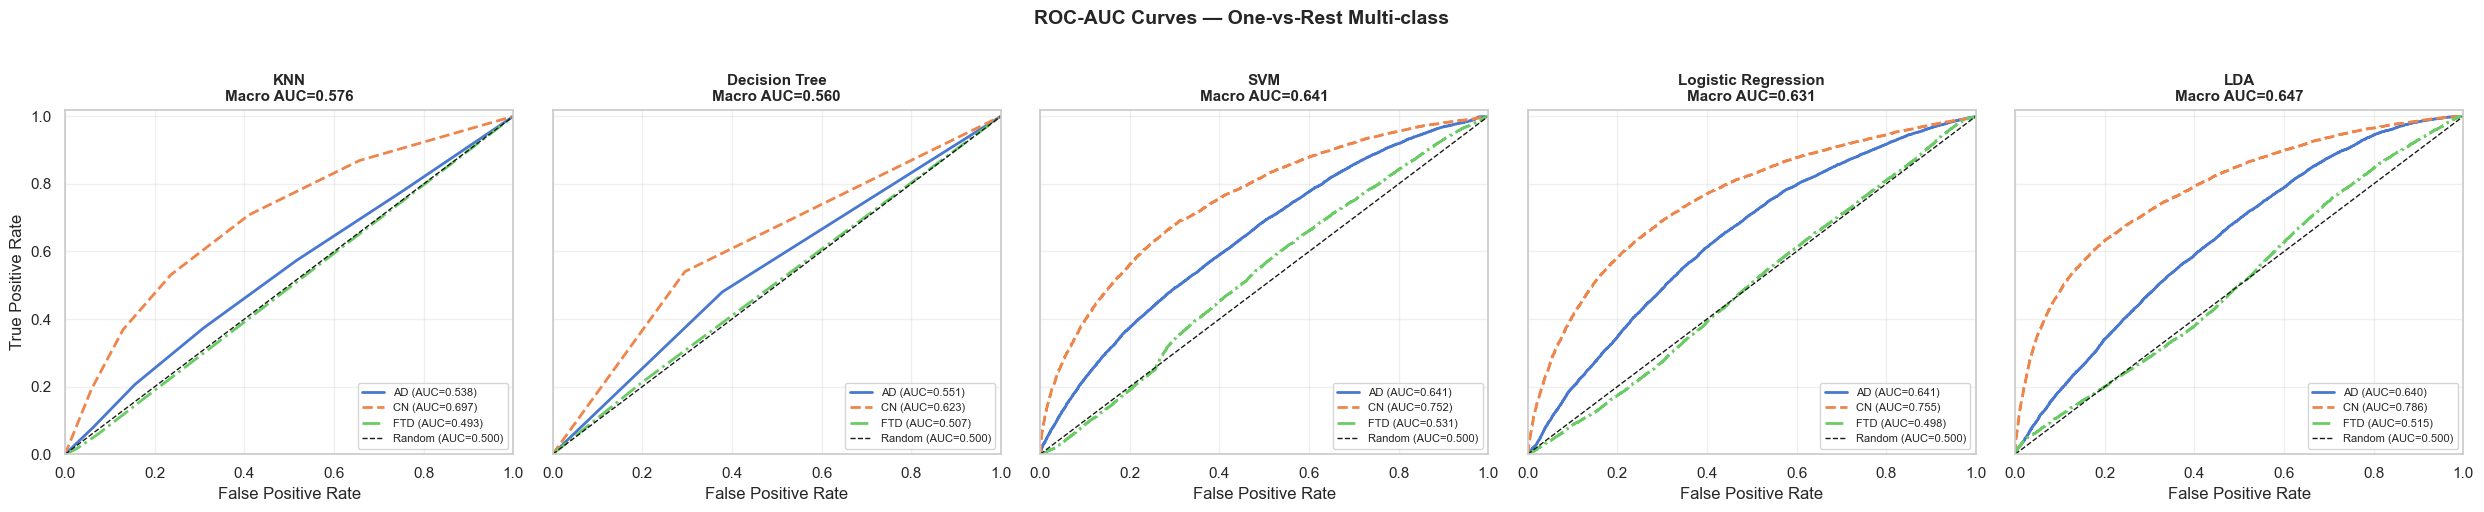

Saved: roc_auc_curves.png


In [8]:
# Binarize labels for One-vs-Rest ROC
y_bin = label_binarize(y, classes=list(range(N_CLASSES)))

colors = cycle(['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#264653'])
line_styles = ['-', '--', '-.', ':', '-']

fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=True)

for ax, (name, color) in zip(axes, zip(MODELS, colors)):
    probas = oof_probas[name]
    
    auc_scores = []
    for i, (cls_name, ls) in enumerate(zip(CLASS_NAMES, line_styles)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probas[:, i])
        roc_auc     = auc(fpr, tpr)
        auc_scores.append(roc_auc)
        ax.plot(fpr, tpr, lw=2, linestyle=ls,
                label=f'{cls_name} (AUC={roc_auc:.3f})')
    
    # Macro-average AUC
    mean_auc = np.mean(auc_scores)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.500)')
    ax.set_title(f'{name}\nMacro AUC={mean_auc:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('True Positive Rate')
fig.suptitle('ROC-AUC Curves — One-vs-Rest Multi-class',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'roc_auc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_auc_curves.png')

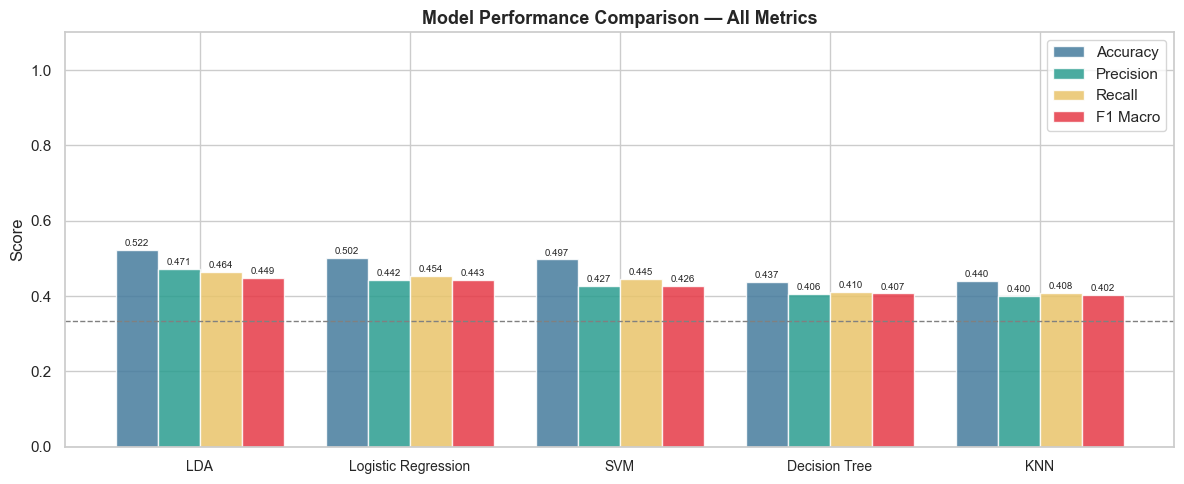

Saved: performance_comparison.png


In [9]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Macro']
x       = np.arange(len(summary_df))
width   = 0.2
palette = ['#457b9d', '#2a9d8f', '#e9c46a', '#e63946']

fig, ax = plt.subplots(figsize=(12, 5))

for i, (metric, color) in enumerate(zip(metrics, palette)):
    bars = ax.bar(x + i * width, summary_df[metric], width,
                  label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(summary_df.index, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.axhline(y=1/N_CLASSES, color='gray', linestyle='--', lw=1,
           label=f'Random baseline ({1/N_CLASSES:.2f})')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'performance_comparison.png'), dpi=150)
plt.show()
print('Saved: performance_comparison.png')

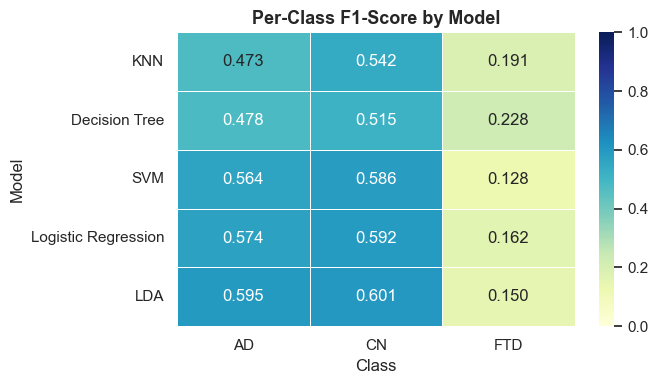

Saved: f1_per_class_heatmap.png


In [10]:
# Build per-class F1 matrix (models × classes)
f1_matrix = []
for name in MODELS:
    report = classification_report(y, oof_preds[name],
                                   target_names=CLASS_NAMES,
                                   output_dict=True, zero_division=0)
    f1_matrix.append([report[cls]['f1-score'] for cls in CLASS_NAMES])

f1_df = pd.DataFrame(f1_matrix, index=list(MODELS.keys()), columns=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(f1_df, annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Per-Class F1-Score by Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'f1_per_class_heatmap.png'), dpi=150)
plt.show()
print('Saved: f1_per_class_heatmap.png')

In [11]:
best_model  = summary_df['F1 Macro'].idxmax()
best_f1     = summary_df.loc[best_model, 'F1 Macro']
best_acc    = summary_df.loc[best_model, 'Accuracy']

print('=' * 55)
print('  FINAL RESULTS SUMMARY')
print('=' * 55)
print(f'  Best model    : {best_model}')
print(f'  Accuracy      : {best_acc:.4f}')
print(f'  F1 Macro      : {best_f1:.4f}')
print('=' * 55)
print(f'\nFiles saved to: {PROCESSED_DIR}')
print('  - confusion_matrices.png')
print('  - roc_auc_curves.png')
print('  - performance_comparison.png')
print('  - f1_per_class_heatmap.png')
print('\n✓ Analysis complete.')

  FINAL RESULTS SUMMARY
  Best model    : LDA
  Accuracy      : 0.5219
  F1 Macro      : 0.4487

Files saved to: ../data/processed/
  - confusion_matrices.png
  - roc_auc_curves.png
  - performance_comparison.png
  - f1_per_class_heatmap.png

✓ Analysis complete.
